In [1]:
import pandas as pd

In [2]:
df = pd.read_csv('flirt_dataset.csv')
df

,Message,Label
0,u looked way too good today omg 😭,flirt
1,forgot my keys again 😩,not_flirt
2,im on my way,not_flirt
3,can’t believe someone like u exists 🥰,flirt
4,that text literally made my day ❤️,flirt
...,...,...
97,wifi acting weird again 😒,not_flirt
98,we need to submit by 6 pm,not_flirt
99,stop making me fall harder 😭,flirt
100,server went down again,not_flirt


In [3]:
x = df['Message']
y = df['Label']

from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.33, random_state=53, stratify=y)

In [4]:
# List of vectorizers to test
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer, HashingVectorizer
vectorizers = {
    "CountVectorizer": CountVectorizer(stop_words='english'),
    "TfidfVectorizer": TfidfVectorizer(stop_words='english'),
    "HashingVectorizer": HashingVectorizer(stop_words='english', alternate_sign=False)
}

In [5]:
from sklearn.naive_bayes import MultinomialNB, ComplementNB, BernoulliNB
from sklearn.linear_model import PassiveAggressiveClassifier, LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier
from sklearn.svm import LinearSVC
from sklearn.pipeline import Pipeline
from sklearn import metrics

In [6]:
classifiers = {
    "MultinomialNB": MultinomialNB(),
    "ComplementNB": ComplementNB(),  
    "BernoulliNB": BernoulliNB(), 
    "PassiveAggressive": PassiveAggressiveClassifier(max_iter=1000, random_state=42),
    "LogisticRegression": LogisticRegression(max_iter=1000, random_state=42),
    "LinearSVC": LinearSVC(random_state=42),  
    "DecisionTree": DecisionTreeClassifier(random_state=42),
    "RandomForest": RandomForestClassifier(n_estimators=100, random_state=42),
    "AdaBoost": AdaBoostClassifier(n_estimators=100, random_state=42),
    "GradientBoosting": GradientBoostingClassifier(n_estimators=100, random_state=42)
}

In [7]:
results = []

for v_name, vectorizer in vectorizers.items():
    for c_name, classifier in classifiers.items():
        text_clf = Pipeline([
            ('vectorizer', vectorizer),
            ('classifier', classifier)
        ])
        text_clf.fit(x_train, y_train)
        y_pred = text_clf.predict(x_test)
        accuracy = metrics.accuracy_score(y_test, y_pred)
        results.append({
            'Vectorizer': v_name,
            'Classifier': c_name,
            'Accuracy': accuracy
        })
        print(f"{v_name} + {c_name}: {accuracy:.3f}")

CountVectorizer + MultinomialNB: 0.765
CountVectorizer + ComplementNB: 0.765
CountVectorizer + BernoulliNB: 0.765
CountVectorizer + PassiveAggressive: 0.735
CountVectorizer + LogisticRegression: 0.765
CountVectorizer + LinearSVC: 0.735
CountVectorizer + DecisionTree: 0.676
CountVectorizer + RandomForest: 0.735
CountVectorizer + AdaBoost: 0.706
CountVectorizer + GradientBoosting: 0.765
TfidfVectorizer + MultinomialNB: 0.765
TfidfVectorizer + ComplementNB: 0.765
TfidfVectorizer + BernoulliNB: 0.765
TfidfVectorizer + PassiveAggressive: 0.735
TfidfVectorizer + LogisticRegression: 0.765
TfidfVectorizer + LinearSVC: 0.735
TfidfVectorizer + DecisionTree: 0.676
TfidfVectorizer + RandomForest: 0.735
TfidfVectorizer + AdaBoost: 0.735
TfidfVectorizer + GradientBoosting: 0.765
HashingVectorizer + MultinomialNB: 0.765
HashingVectorizer + ComplementNB: 0.765
HashingVectorizer + BernoulliNB: 0.765
HashingVectorizer + PassiveAggressive: 0.735
HashingVectorizer + LogisticRegression: 0.765
HashingVector

In [8]:
results_df = pd.DataFrame(results)
results_df = results_df.sort_values(by='Accuracy', ascending=False).reset_index(drop=True)
print("\nTop 3 performing model combinations:\n")
print(results_df.head(3))


Top 3 performing model combinations:

        Vectorizer     Classifier  Accuracy
0  CountVectorizer  MultinomialNB  0.764706
1  CountVectorizer   ComplementNB  0.764706
2  CountVectorizer    BernoulliNB  0.764706


#### Creating the model for the best combination

In [9]:
from sklearn.feature_extraction.text import CountVectorizer
vectorizer = CountVectorizer(stop_words='english')
x_vec = vectorizer.fit_transform(df['Message'])
y = df['Label']

from sklearn.naive_bayes import MultinomialNB
model = MultinomialNB()
model.fit(x_vec, y)

,alpha,1.0
,force_alpha,True
,fit_prior,True
,class_prior,None


In [10]:
from joblib import dump

In [11]:
dump(model, 'best_flirt_model.joblib')
dump(vectorizer, 'best_vectorizer.joblib')

['best_vectorizer.joblib']

## Predicting Whatsapp chats

In [12]:
from joblib import load

In [13]:
model = load('best_flirt_model.joblib')
vectorizer = load('best_vectorizer.joblib')

In [14]:
dataset=pd.read_csv('whatsapp_chat.csv')
dataset

,Date,Time,Name,Chat
0,06/07/23,6:45 pm,Jeya,Aththai sirippu thaan highlight 😘😘😘
1,06/07/23,6:45 pm,Jeya,Happy 25th anniversary aththai mama
2,19/07/23,6:25 am,Roseline,Happy birthday anna 🎁💐🥳 stay blessed
3,19/07/23,10:51 am,Jeya,Tq papa 🤗😘
4,21/07/23,8:00 pm,Jeya,😍
...,...,...,...,...
107,19/07/25,9:42 am,Jeya,Done ✨
108,03/08/25,12:25 pm,Roseline,Happy birthday thangam
109,03/08/25,12:27 pm,Jeya,Thank u aththai ✨🤓
110,08/09/25,7:40 am,Jeya,Happy birthday thambi 🎂


In [15]:
dataset.dropna(subset=['Chat'], inplace=True)

In [16]:
X_vec = vectorizer.transform(dataset['Chat'])
dataset['Flirt_Prediction'] = model.predict(X_vec)
dataset

,Date,Time,Name,Chat,Flirt_Prediction
0,06/07/23,6:45 pm,Jeya,Aththai sirippu thaan highlight 😘😘😘,flirt
1,06/07/23,6:45 pm,Jeya,Happy 25th anniversary aththai mama,flirt
2,19/07/23,6:25 am,Roseline,Happy birthday anna 🎁💐🥳 stay blessed,not_flirt
3,19/07/23,10:51 am,Jeya,Tq papa 🤗😘,flirt
4,21/07/23,8:00 pm,Jeya,😍,flirt
...,...,...,...,...,...
107,19/07/25,9:42 am,Jeya,Done ✨,flirt
108,03/08/25,12:25 pm,Roseline,Happy birthday thangam,flirt
109,03/08/25,12:27 pm,Jeya,Thank u aththai ✨🤓,flirt
110,08/09/25,7:40 am,Jeya,Happy birthday thambi 🎂,flirt


C:\Users\Admin\AppData\Local\Temp\ipykernel_2112\1097490249.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Flirt_Prediction', data=dataset, palette='cool')


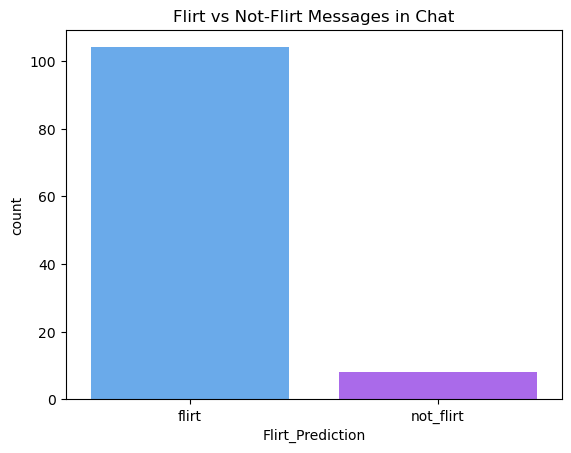

In [17]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='Flirt_Prediction', data=dataset, palette='cool')
plt.title("Flirt vs Not-Flirt Messages in Chat")
plt.show()


In [18]:
top_senders = dataset['Name'].value_counts().reset_index()
top_senders.columns = ['Name', 'Message_Count']
top_senders

,Name,Message_Count
0,Jeya,66
1,Roseline,46


C:\Users\Admin\AppData\Local\Temp\ipykernel_2112\13167715.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Name', y='Message_Count', data=top_senders, palette='viridis')


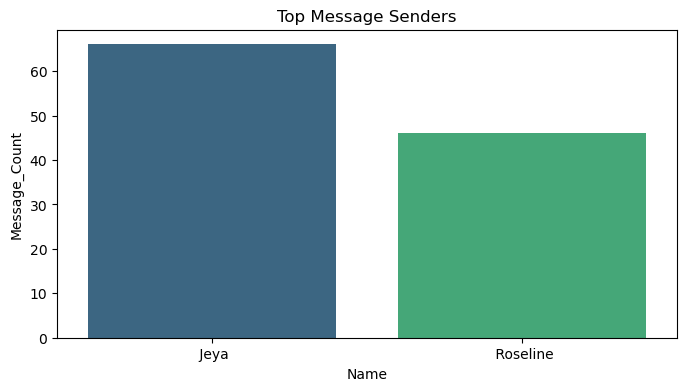

In [19]:
plt.figure(figsize=(8,4))
sns.barplot(x='Name', y='Message_Count', data=top_senders, palette='viridis')
plt.title('Top Message Senders')
plt.show()

In [20]:
pd.to_datetime("10:45 PM", format='%I:%M %p')

#The format argument tells pandas exactly what structure to expect:
# %I → hour in 12-hour format (1–12)
# %M → minute (00–59)
# %p → AM or PM

Timestamp('1900-01-01 22:45:00')

In [21]:
dataset['Time'] = dataset['Time'].str.replace('\u202f', ' ', regex=True).str.strip()

In [22]:
# Convert clean time (like "6:45 pm") to 24-hour format
dataset['Time_24'] = pd.to_datetime(dataset['Time'], format='%I:%M %p', errors='coerce').dt.time

# Extract hour (0–23)
dataset['Hour'] = pd.to_datetime(dataset['Time'], format='%I:%M %p', errors='coerce').dt.hour

In [23]:
dataset

,Date,Time,Name,Chat,Flirt_Prediction,Time_24,Hour
0,06/07/23,6:45 pm,Jeya,Aththai sirippu thaan highlight 😘😘😘,flirt,18:45:00,18
1,06/07/23,6:45 pm,Jeya,Happy 25th anniversary aththai mama,flirt,18:45:00,18
2,19/07/23,6:25 am,Roseline,Happy birthday anna 🎁💐🥳 stay blessed,not_flirt,06:25:00,6
3,19/07/23,10:51 am,Jeya,Tq papa 🤗😘,flirt,10:51:00,10
4,21/07/23,8:00 pm,Jeya,😍,flirt,20:00:00,20
...,...,...,...,...,...,...,...
107,19/07/25,9:42 am,Jeya,Done ✨,flirt,09:42:00,9
108,03/08/25,12:25 pm,Roseline,Happy birthday thangam,flirt,12:25:00,12
109,03/08/25,12:27 pm,Jeya,Thank u aththai ✨🤓,flirt,12:27:00,12
110,08/09/25,7:40 am,Jeya,Happy birthday thambi 🎂,flirt,07:40:00,7


In [24]:
def get_time_category(hour):
    if pd.isna(hour):
        return 'Unknown'
    elif 5 <= hour < 12:
        return 'Morning'
    elif 12 <= hour < 17:
        return 'Noon'
    elif 17 <= hour < 21:
        return 'Evening'
    else:
        return 'Night'

In [25]:
dataset['Time_category'] = dataset['Hour'].apply(get_time_category)
dataset

,Date,Time,Name,Chat,Flirt_Prediction,Time_24,Hour,Time_category
0,06/07/23,6:45 pm,Jeya,Aththai sirippu thaan highlight 😘😘😘,flirt,18:45:00,18,Evening
1,06/07/23,6:45 pm,Jeya,Happy 25th anniversary aththai mama,flirt,18:45:00,18,Evening
2,19/07/23,6:25 am,Roseline,Happy birthday anna 🎁💐🥳 stay blessed,not_flirt,06:25:00,6,Morning
3,19/07/23,10:51 am,Jeya,Tq papa 🤗😘,flirt,10:51:00,10,Morning
4,21/07/23,8:00 pm,Jeya,😍,flirt,20:00:00,20,Evening
...,...,...,...,...,...,...,...,...
107,19/07/25,9:42 am,Jeya,Done ✨,flirt,09:42:00,9,Morning
108,03/08/25,12:25 pm,Roseline,Happy birthday thangam,flirt,12:25:00,12,Noon
109,03/08/25,12:27 pm,Jeya,Thank u aththai ✨🤓,flirt,12:27:00,12,Noon
110,08/09/25,7:40 am,Jeya,Happy birthday thambi 🎂,flirt,07:40:00,7,Morning


Text(0.5, 1.0, 'Frequency by the time of the day')

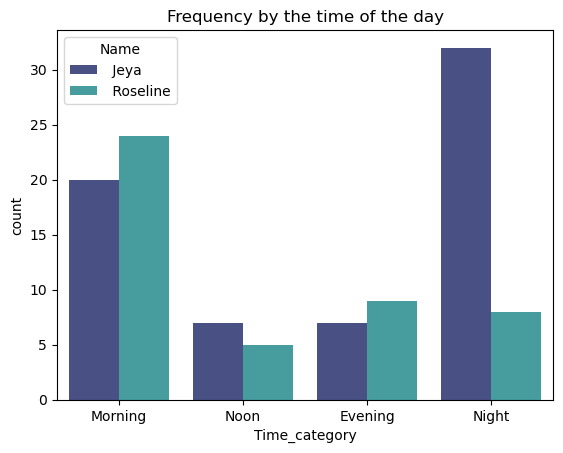

In [26]:
sns.countplot(x = 'Time_category',hue = 'Name',data=dataset,order=['Morning','Noon','Evening','Night'],palette='mako')
plt.title('Frequency by the time of the day')

In [28]:
dataset['Date'] = pd.to_datetime(dataset['Date'], errors='coerce')

C:\Users\Admin\AppData\Local\Temp\ipykernel_2112\2461843626.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  dataset['Date'] = pd.to_datetime(dataset['Date'], errors='coerce')


In [29]:
date_activity = dataset.groupby(['Date', 'Name']).size().unstack(fill_value=0)

Text(50.722222222222214, 0.5, 'Person')

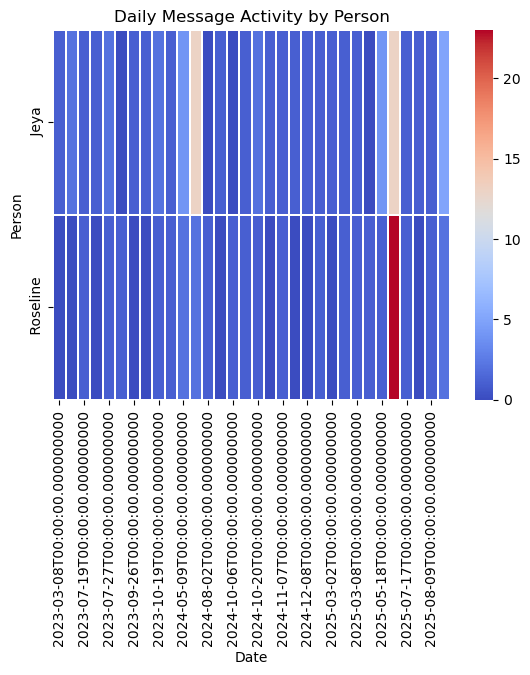

In [30]:
sns.heatmap(date_activity.T, cmap='coolwarm', linewidths=0.3)
plt.title("Daily Message Activity by Person")
plt.xlabel("Date")
plt.ylabel("Person")

In [31]:
dataset['Day'] = dataset['Date'].dt.day_name()

In [32]:
dataset

,Date,Time,Name,Chat,Flirt_Prediction,Time_24,Hour,Time_category,Day
0,2023-06-07,6:45 pm,Jeya,Aththai sirippu thaan highlight 😘😘😘,flirt,18:45:00,18,Evening,Wednesday
1,2023-06-07,6:45 pm,Jeya,Happy 25th anniversary aththai mama,flirt,18:45:00,18,Evening,Wednesday
2,2023-07-19,6:25 am,Roseline,Happy birthday anna 🎁💐🥳 stay blessed,not_flirt,06:25:00,6,Morning,Wednesday
3,2023-07-19,10:51 am,Jeya,Tq papa 🤗😘,flirt,10:51:00,10,Morning,Wednesday
4,2023-07-21,8:00 pm,Jeya,😍,flirt,20:00:00,20,Evening,Friday
...,...,...,...,...,...,...,...,...,...
107,2025-07-19,9:42 am,Jeya,Done ✨,flirt,09:42:00,9,Morning,Saturday
108,2025-03-08,12:25 pm,Roseline,Happy birthday thangam,flirt,12:25:00,12,Noon,Saturday
109,2025-03-08,12:27 pm,Jeya,Thank u aththai ✨🤓,flirt,12:27:00,12,Noon,Saturday
110,2025-08-09,7:40 am,Jeya,Happy birthday thambi 🎂,flirt,07:40:00,7,Morning,Saturday


In [34]:
day_counts = dataset['Day'].value_counts()
day_counts

Day
Monday       40
Friday       27
Thursday     16
Sunday       13
Wednesday     6
Saturday      6
Tuesday       4
Name: count, dtype: int64

<Axes: xlabel='Day', ylabel='count'>

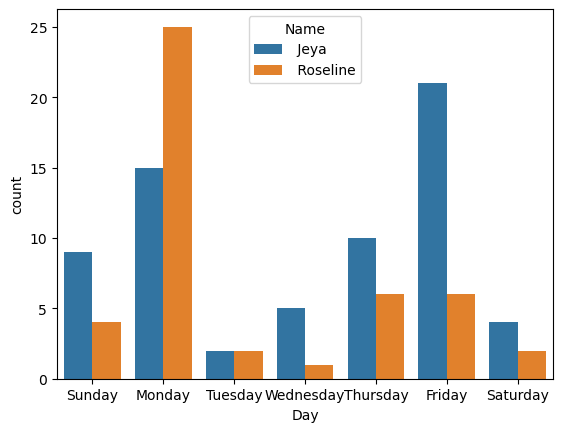

In [37]:
sns.countplot(x='Day',hue='Name',order=['Sunday','Monday','Tuesday','Wednesday','Thursday','Friday','Saturday'],data=dataset)

In [40]:
time_counts = dataset['Hour'].value_counts()
time_counts

Hour
22    28
11    16
8     14
21    11
10    10
18     5
17     5
20     4
13     3
12     3
6      2
19     2
14     2
16     2
15     2
23     1
9      1
7      1
Name: count, dtype: int64

Text(0, 0.5, 'Message counts')

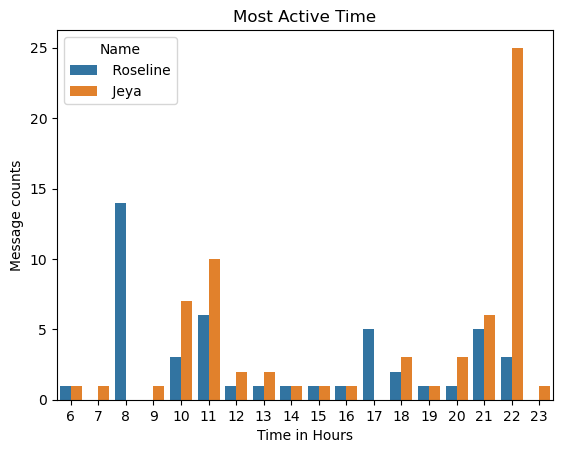

In [45]:
sns.countplot(x='Hour',hue='Name',data=dataset)
plt.title('Most Active Time')
plt.xlabel('Time in Hours')
plt.ylabel('Message counts')

In [46]:
dataset['Is_Media'] = dataset['Chat'].str.contains('omitted|media', case=False, na=False)

In [47]:
dataset

,Date,Time,Name,Chat,Flirt_Prediction,Time_24,Hour,Time_category,Day,Is_Media
0,2023-06-07,6:45 pm,Jeya,Aththai sirippu thaan highlight 😘😘😘,flirt,18:45:00,18,Evening,Wednesday,False
1,2023-06-07,6:45 pm,Jeya,Happy 25th anniversary aththai mama,flirt,18:45:00,18,Evening,Wednesday,False
2,2023-07-19,6:25 am,Roseline,Happy birthday anna 🎁💐🥳 stay blessed,not_flirt,06:25:00,6,Morning,Wednesday,False
3,2023-07-19,10:51 am,Jeya,Tq papa 🤗😘,flirt,10:51:00,10,Morning,Wednesday,False
4,2023-07-21,8:00 pm,Jeya,😍,flirt,20:00:00,20,Evening,Friday,False
...,...,...,...,...,...,...,...,...,...,...
107,2025-07-19,9:42 am,Jeya,Done ✨,flirt,09:42:00,9,Morning,Saturday,False
108,2025-03-08,12:25 pm,Roseline,Happy birthday thangam,flirt,12:25:00,12,Noon,Saturday,False
109,2025-03-08,12:27 pm,Jeya,Thank u aththai ✨🤓,flirt,12:27:00,12,Noon,Saturday,False
110,2025-08-09,7:40 am,Jeya,Happy birthday thambi 🎂,flirt,07:40:00,7,Morning,Saturday,False


In [48]:
dataset['Is_Media'].value_counts()

Is_Media
False    83
True     29
Name: count, dtype: int64

In [50]:
media_counts = dataset.groupby('Name')['Is_Media'].sum()
media_counts

Name
Jeya        17
Roseline    12
Name: Is_Media, dtype: int64

C:\Users\Admin\AppData\Local\Temp\ipykernel_2112\4048141973.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=media_counts.index, y=media_counts.values, palette='pastel')


Text(0, 0.5, 'Media Message Count')

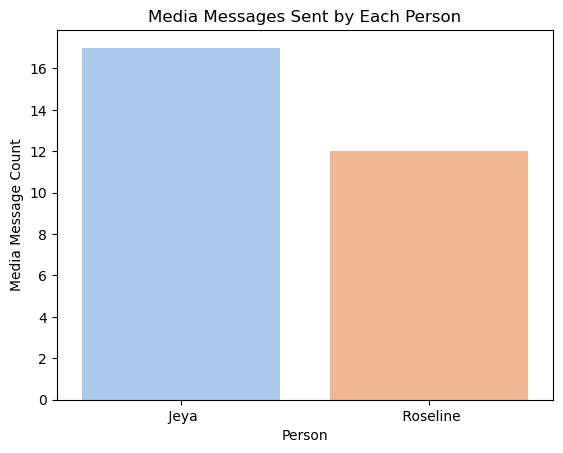

In [51]:
sns.barplot(x=media_counts.index, y=media_counts.values, palette='pastel')
plt.title("Media Messages Sent by Each Person")
plt.xlabel("Person")
plt.ylabel("Media Message Count")